## importing library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error
)

## Load dataset

In [5]:
df = pd.read_csv("swarm.csv")

print(df.head())
print(df.shape)
print(df.info())

           X          Y  OBJECTID        STARTDATE  TmSTARTDAT  \
0 -15.131944  17.870278         1  30-11-1985 0.00        12.0   
1 -15.400278  18.030833         2  26-11-1985 0.00        12.0   
2 -14.668889  17.988889         3  27-11-1985 0.00        12.0   
3 -14.633333  17.835833         4  30-11-1985 0.00        12.0   
4 -13.353889  18.026389         5  15-10-1985 0.00        12.0   

        FINISHDATE  TmFINISHDA EXACTDATE PARTMONTH LOCNAME  ...  CTLQTYU  \
0  30-11-1985 0.00        12.0        No      Late          ...            
1  26-11-1985 0.00        12.0        No      Late          ...            
2  27-11-1985 0.00        12.0        No      Late          ...            
3  30-11-1985 0.00        12.0        No      Late          ...            
4  15-10-1985 0.00        12.0       Yes                    ...            

  CTLARTREA CTLARTREAU  CTLAPPHAND CTLAPPVEHI CTLAPPAIR  CTLAPPMECH  \
0       0.0                      0          0         0           0   
1   

## Filling missing values

In [33]:
# Fill missing values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Encoding Completed")
print(df.select_dtypes(include='object').columns)

Encoding Completed
Index([], dtype='object')


## Label Encoder

In [25]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Encoding Completed")

Encoding Completed


In [37]:
date_cols = ['STARTDATE', 'FINISHDATE', 'EXACTDATE', 'CTLSTDATE', 'CTLFNDATE']
df.drop(columns=date_cols, inplace=True, errors='ignore')

## Target Column

In [38]:
TARGET_COLUMN = 'LOCPRESENT'

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

## Standard Scaler

In [39]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

## Testing

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


===== LOGISTIC REGRESSION HYPERPARAMETERS =====
Penalty      : l2
Solver       : lbfgs
C Value      : 1.0
Max Iterations: 1000
Random State : 42


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


===== LOGISTIC REGRESSION RESULTS =====
Accuracy : 0.9967670580228007
Precision: 0.9967659574468085
Recall   : 1.0
F1 Score : 0.9983803597306282
ROC AUC  : 0.9186182669789227

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      5856
           2       1.00      0.10      0.17        21

    accuracy                           1.00      5877
   macro avg       1.00      0.55      0.59      5877
weighted avg       1.00      1.00      1.00      5877



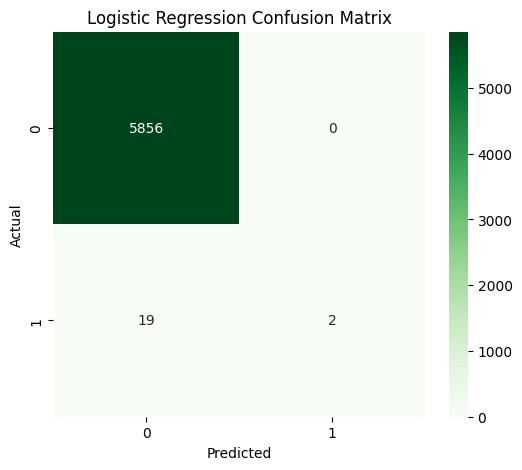

In [41]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

print("===== LOGISTIC REGRESSION HYPERPARAMETERS =====")
print("Penalty      :", log_model.penalty)
print("Solver       :", log_model.solver)
print("C Value      :", log_model.C)
print("Max Iterations:", log_model.max_iter)
print("Random State :", log_model.random_state)

log_model.fit(X_train, y_train)

# Train model
log_model.fit(X_train, y_train)

# Predictions
log_pred = log_model.predict(X_test)

# Probability predictions
log_prob = log_model.predict_proba(X_test)[:,1]

# Metrics
print("===== LOGISTIC REGRESSION RESULTS =====")

print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC AUC  :", roc_auc_score(y_test, log_prob))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
# P(y)=1/1+e−z1